# Energy-Based Text Simplification with Latent Layer Intervention

This notebook implements an energy-based guidance framework for controlled text simplification using GPT-2. Three approaches are compared: a baseline (no intervention), COLD decoding with an energy-based selector, and a combined method that adds latent-layer fine-tuning on top of COLD decoding.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from typing import List, Tuple
import copy


class Config:
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    MODEL_NAME = "gpt2"

    # COLD decoding energy weights
    W_PPL = 1.0
    W_LEN = 0.5
    W_VOCAB = 0.3
    NUM_CANDIDATES = 5

    # Latent fine-tuning
    TARGET_LAYER = 4
    LAMBDA = 1.0
    NUM_FINETUNE_EXAMPLES = 100
    LEARNING_RATE = 1e-5
    NUM_EPOCHS = 10

    # Generation
    MAX_TOKENS = 40
    MAX_LENGTH = 512
    TOP_K = 50
    TEMPERATURE = 1.0


torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)

## Setup: Model and Dataset

In [2]:
tokenizer = GPT2Tokenizer.from_pretrained(Config.MODEL_NAME)
base_model = GPT2LMHeadModel.from_pretrained(Config.MODEL_NAME).to(Config.DEVICE)
base_model.eval()
tokenizer.pad_token = tokenizer.eos_token

ds_train = load_dataset("facebook/asset", "simplification", split="validation")
ds_test = load_dataset("facebook/asset", "simplification", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

simplification/validation-00000-of-00001(…):   0%|          | 0.00/885k [00:00<?, ?B/s]

simplification/test-00000-of-00001.parqu(…):   0%|          | 0.00/170k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/359 [00:00<?, ? examples/s]

## Latent Layer Fine-Tuning

Fine-tunes a single GPT-2 transformer block using forward hooks. For each (complex, simple) pair, the hook captures mean-pooled hidden states at the target layer and minimizes an L2 + cosine similarity loss to pull complex sentence embeddings toward their simple counterparts.

In [3]:
def compute_latent_loss(
    e: torch.Tensor,
    e_p: torch.Tensor,
    lambda_weight: float = Config.LAMBDA
) -> torch.Tensor:
    """
    L(e) = ||e - e_p||^2 + lambda * (1 - cos(e, e_p))

    Pushes complex embeddings toward simple embeddings at the target layer.
    """
    l2_loss = torch.sum((e - e_p) ** 2)
    e_norm = e / (e.norm() + 1e-8)
    e_p_norm = e_p / (e_p.norm() + 1e-8)
    similarity_loss = 1.0 - torch.sum(e_norm * e_p_norm)
    return l2_loss + lambda_weight * similarity_loss


def finetune_latent_layer(
    model: GPT2LMHeadModel,
    train_pairs: List[Tuple[str, str]],
    layer_idx: int = Config.TARGET_LAYER,
    num_epochs: int = Config.NUM_EPOCHS,
    lr: float = Config.LEARNING_RATE
) -> GPT2LMHeadModel:
    """
    Fine-tune a single GPT-2 layer using forward hooks.

    For each (complex, simple) pair:
      1. Register a hook on the target layer to capture mean-pooled embeddings.
      2. Forward pass on simple sentence -> e_p (no grad, frozen).
      3. Forward pass on complex sentence -> e (with grad).
      4. Compute loss and backprop through the target layer only.
    """
    finetuned_model = copy.deepcopy(model)
    finetuned_model.train()

    target_layer = finetuned_model.transformer.h[layer_idx]
    optimizer = torch.optim.Adam(target_layer.parameters(), lr=lr)

    hook_storage = {"complex_embedding": None, "simple_embedding": None, "mode": None}

    def capture_hook(module, input, output):
        hidden_states = output[0]
        avg_pooled = hidden_states[0].mean(dim=0)
        if hook_storage["mode"] == "complex":
            hook_storage["complex_embedding"] = avg_pooled
        elif hook_storage["mode"] == "simple":
            hook_storage["simple_embedding"] = avg_pooled
        return output

    hook_handle = target_layer.register_forward_hook(capture_hook)

    try:
        for epoch in range(num_epochs):
            epoch_loss = 0.0
            for complex_sent, simple_sent in train_pairs:
                complex_enc = tokenizer(
                    complex_sent, return_tensors="pt", truncation=True, max_length=100
                ).to(Config.DEVICE)
                simple_enc = tokenizer(
                    simple_sent, return_tensors="pt", truncation=True, max_length=100
                ).to(Config.DEVICE)

                hook_storage["mode"] = "simple"
                with torch.no_grad():
                    finetuned_model.transformer(simple_enc["input_ids"])
                e_p = hook_storage["simple_embedding"].detach()

                hook_storage["mode"] = "complex"
                finetuned_model.transformer(complex_enc["input_ids"])
                e = hook_storage["complex_embedding"]

                loss = compute_latent_loss(e, e_p)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            print(f"Epoch {epoch+1}/{num_epochs}: Loss = {epoch_loss / len(train_pairs):.4f}")
    finally:
        hook_handle.remove()

    finetuned_model.eval()
    return finetuned_model


train_pairs = [
    (ds_train[i]["original"], ds_train[i]["simplifications"][0])
    for i in range(Config.NUM_FINETUNE_EXAMPLES)
]

finetuned_model = finetune_latent_layer(base_model, train_pairs)

Epoch 1/10: Loss = 1941.2896
Epoch 2/10: Loss = 1873.3925
Epoch 3/10: Loss = 1737.9031
Epoch 4/10: Loss = 1924.4055
Epoch 5/10: Loss = 1991.7443
Epoch 6/10: Loss = 2037.3781
Epoch 7/10: Loss = 2563.8550
Epoch 8/10: Loss = 3064.8622
Epoch 9/10: Loss = 3855.5735
Epoch 10/10: Loss = 4489.4822


## Energy Function and COLD Decoding

The energy function scores each candidate output as a weighted sum of perplexity (fluency), length (brevity), and vocabulary commonality (simplicity). COLD decoding generates N candidates and returns the one with the lowest energy.

In [4]:
COMMON_WORDS = set([
    "the", "be", "to", "of", "and", "a", "in", "that", "have", "i",
    "it", "for", "not", "on", "with", "he", "as", "you", "do", "at",
    "this", "but", "his", "by", "from", "they", "we", "say", "her", "she",
    "or", "an", "will", "my", "one", "all", "would", "there", "their",
    "what", "so", "up", "out", "if", "about", "who", "get", "which", "go", "me",
    "when", "make", "can", "like", "time", "no", "just", "him", "know", "take",
    "people", "into", "year", "your", "good", "some", "could", "them", "see",
    "other", "than", "then", "now", "look", "only", "come", "its", "over",
    "think", "also", "back", "after", "use", "two", "how", "our", "work",
    "first", "well", "way", "even", "new", "want", "because", "any", "these",
    "give", "day", "most", "us", "is", "was", "are", "been", "has", "had",
    "were", "said", "did", "having", "may", "should", "could", "would"
])


def compute_energy(
    text: str,
    model: GPT2LMHeadModel,
    w_ppl: float = Config.W_PPL,
    w_len: float = Config.W_LEN,
    w_vocab: float = Config.W_VOCAB
) -> float:
    """
    E(y) = w1 * PPL(y) + w2 * len(y) + w3 * (1 - vocab_commonality(y))

    Lower energy = simpler and more fluent output.
    """
    if not text or not text.strip():
        return float("inf")

    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=100).to(Config.DEVICE)
    with torch.no_grad():
        outputs = model(**enc, labels=enc["input_ids"])
        ppl = torch.exp(outputs.loss).item()

    words = text.lower().split()
    vocab_commonality = sum(1 for w in words if w in COMMON_WORDS) / max(len(words), 1)
    energy = w_ppl * ppl + w_len * len(words) + w_vocab * (1.0 - vocab_commonality)
    return energy


def cold_generate(
    prompt: str,
    model: GPT2LMHeadModel,
    num_candidates: int = Config.NUM_CANDIDATES,
    max_new_tokens: int = Config.MAX_TOKENS,
    verbose: bool = False
) -> str:
    """
    Generate N candidates and return the one with the lowest energy score.
    """
    context = f"Simplify: {prompt}\nSimple:"
    enc = tokenizer(context, return_tensors="pt", truncation=True, max_length=512).to(Config.DEVICE)

    candidates = []
    for _ in range(num_candidates):
        with torch.no_grad():
            output_ids = model.generate(
                enc["input_ids"],
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=Config.TEMPERATURE,
                top_k=Config.TOP_K,
                pad_token_id=tokenizer.eos_token_id
            )
        full_output = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        if "Simple:" in full_output:
            try:
                candidate = full_output.split("Simple:")[1].split("\n")[0].strip()
            except Exception:
                candidate = full_output.strip()
        else:
            candidate = full_output.strip()
        candidates.append(candidate)

    energies = [compute_energy(c, model) for c in candidates]
    best_idx = int(np.argmin(energies))

    if verbose:
        for i, (cand, energy) in enumerate(zip(candidates, energies)):
            marker = "<-- selected" if i == best_idx else ""
            print(f"  [{i+1}] E={energy:.2f} {marker}: {cand[:60]}")

    return candidates[best_idx]

## Generation Wrappers

In [5]:
def baseline_generate(prompt: str, max_new_tokens: int = Config.MAX_TOKENS) -> str:
    """Standard GPT-2 generation with a simplification prompt. No energy selection."""
    context = f"Simplify: {prompt}\nSimple:"
    enc = tokenizer(context, return_tensors="pt", truncation=True, max_length=512).to(Config.DEVICE)
    with torch.no_grad():
        output_ids = base_model.generate(
            enc["input_ids"],
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=Config.TEMPERATURE,
            top_k=Config.TOP_K,
            pad_token_id=tokenizer.eos_token_id
        )
    full_output = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    if "Simple:" in full_output:
        try:
            return full_output.split("Simple:")[1].split("\n")[0].strip()
        except Exception:
            return full_output.strip()
    return full_output.strip()


def cold_only_generate(prompt: str, verbose: bool = False) -> str:
    """COLD decoding on the base model. Energy selection, no latent fine-tuning."""
    return cold_generate(prompt, base_model, verbose=verbose)


def combined_generate(prompt: str, verbose: bool = False) -> str:
    """COLD decoding on the fine-tuned model. Both latent intervention and energy selection."""
    return cold_generate(prompt, finetuned_model, verbose=verbose)

In [6]:
!pip install -q bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00


## Single Example: Qualitative Check

In [7]:
test_src = ds_test[0]["original"]
test_ref = ds_test[0]["simplifications"][0]

print(f"Source:    {test_src}")
print(f"Reference: {test_ref}\n")

baseline_out = baseline_generate(test_src)
print(f"Baseline:  {baseline_out}\n")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
cold_out = cold_only_generate(test_src, verbose=True)
print(f"COLD:      {cold_out}\n")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
combined_out = combined_generate(test_src, verbose=True)
print(f"Combined:  {combined_out}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Source:    One side of the armed conflicts is composed mainly of the Sudanese military and the Janjaweed, a Sudanese militia group recruited mostly from the Afro-Arab Abbala tribes of the northern Rizeigat region in Sudan.
Reference: On one side of the conflicts are the Sudanese military and the Janjaweed, a Sudanese militia group.  They are mostly recruited from the Afro-Arab Abbala tribes.

Baseline:  You'd think the military would be quite friendly with Sudan's neighbours and might even ask some questions, and so on. I don't know how many people from Juba are in the armed conflicts in



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  [1] E=33.18 <-- selected: The armed conflicts in northern Sudan are divided into three
  [2] E=48.98 : The first stage in this war is to control the Juba people [s
  [3] E=42.19 : The Janjaweed militia have been working for several years on
  [4] E=41.03 : There is no such thing as too much, not including those peop
  [5] E=35.92 : Sudanese security forces, especially after the independence 
COLD:      The armed conflicts in northern Sudan are divided into three parts, each based on a different occupation of territory. The first part is dominated by the Janjaweed, with a smaller number of Sudanese

  [1] E=135.02 : A woman holds up violence and the security has, he explains,
  [2] E=148.31 : the the the Nax, a the the a (P.P to offer 1, who asked some
  [3] E=144.72 : The group, says a a local politician says the former dictato
  [4] E=88.31 <-- selected: No guns, said, he says that you have been arrested because h
  [5] E=114.11 : The first suspect, a former police accused in a vete

## Evaluation Metrics

In [8]:
def compute_flesch(text: str) -> float:
    """Compute Flesch Reading Ease score. Higher = simpler."""
    if not text or not text.strip():
        return 0.0

    sentences = [s.strip() for s in text.replace("!", ".").replace("?", ".").split(".") if s.strip()]
    num_sentences = max(len(sentences), 1)
    words = text.split()
    num_words = max(len(words), 1)

    def count_syllables(word):
        word = word.lower()
        vowels = "aeiouy"
        count, prev_vowel = 0, False
        for char in word:
            is_vowel = char in vowels
            if is_vowel and not prev_vowel:
                count += 1
            prev_vowel = is_vowel
        if word.endswith("e"):
            count -= 1
        return max(count, 1)

    num_syllables = sum(count_syllables(w) for w in words)
    return 206.835 - 1.015 * (num_words / num_sentences) - 84.6 * (num_syllables / num_words)

## Full Evaluation (Ablation Study)

Runs all three approaches on `n_examples` test sentences and reports Flesch Reading Ease and BERTScore F1.

In [12]:
import numpy as np
from bert_score import score as bert_score


def evaluate_all_approaches(n_examples: int = 50):
    """
    Compare baseline, COLD-only, and combined across n_examples test sentences.

    Metrics:
      - Flesch Reading Ease (higher = simpler)
      - BERTScore F1 (higher = better semantic fidelity)
    """
    test_subset = list(ds_test.select(range(n_examples)))

    sources, references = [], []
    baseline_outputs, cold_only_outputs, combined_outputs = [], [], []

    for i, example in enumerate(test_subset):
        src = example["original"]
        ref = example["simplifications"][0] if example["simplifications"] else ""
        sources.append(src)
        references.append(ref)

        try:
            baseline_outputs.append(baseline_generate(src))
        except Exception:
            baseline_outputs.append("")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        try:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            cold_only_outputs.append(cold_only_generate(src))
        except Exception:
            cold_only_outputs.append(baseline_outputs[-1])
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        try:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            combined_outputs.append(combined_generate(src))
        except Exception:
            combined_outputs.append(baseline_outputs[-1])
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"{i+1}/{n_examples} done")

    baseline_flesch = [compute_flesch(s) for s in baseline_outputs]
    cold_flesch = [compute_flesch(s) for s in cold_only_outputs]
    combined_flesch = [compute_flesch(s) for s in combined_outputs]
    ref_flesch = [compute_flesch(s) for s in references]

    _, _, F1_baseline = bert_score(baseline_outputs, references, lang="en", verbose=False)
    _, _, F1_cold = bert_score(cold_only_outputs, references, lang="en", verbose=False)
    _, _, F1_combined = bert_score(combined_outputs, references, lang="en", verbose=False)

    print("\nReadability (Flesch Reading Ease) -- higher is simpler")
    print(f"  Baseline:  {np.mean(baseline_flesch):.1f} +/- {np.std(baseline_flesch):.1f}")
    print(f"  COLD only: {np.mean(cold_flesch):.1f} +/- {np.std(cold_flesch):.1f}  (delta={np.mean(cold_flesch)-np.mean(baseline_flesch):+.1f})")
    print(f"  Combined:  {np.mean(combined_flesch):.1f} +/- {np.std(combined_flesch):.1f}  (delta={np.mean(combined_flesch)-np.mean(baseline_flesch):+.1f})")
    print(f"  Reference: {np.mean(ref_flesch):.1f} +/- {np.std(ref_flesch):.1f}")

    print("\nSemantic Fidelity (BERTScore F1) -- higher is better")
    print(f"  Baseline:  {F1_baseline.mean():.3f} +/- {F1_baseline.std():.3f}")
    print(f"  COLD only: {F1_cold.mean():.3f} +/- {F1_cold.std():.3f}  (delta={F1_cold.mean()-F1_baseline.mean():+.3f})")
    print(f"  Combined:  {F1_combined.mean():.3f} +/- {F1_combined.std():.3f}  (delta={F1_combined.mean()-F1_baseline.mean():+.3f})")

    cold_improvement = np.mean(cold_flesch) - np.mean(baseline_flesch)
    latent_contribution = np.mean(combined_flesch) - np.mean(cold_flesch)
    print(f"\nCOLD decoding contribution:      {cold_improvement:+.1f} Flesch points")
    print(f"Latent fine-tuning contribution: {latent_contribution:+.1f} Flesch points")

    print("\nExample outputs (first 50):")
    for i in range(min(50, n_examples)):
        print(f"\n[{i+1}] Source:    {sources[i]}")
        print(f"    Baseline:  {baseline_outputs[i]}  (Flesch={baseline_flesch[i]:.1f})")
        print(f"    COLD only: {cold_only_outputs[i]}  (Flesch={cold_flesch[i]:.1f})")
        print(f"    Combined:  {combined_outputs[i]}  (Flesch={combined_flesch[i]:.1f})")
        print(f"    Reference: {references[i]}  (Flesch={ref_flesch[i]:.1f})")

    return {
        "sources": sources,
        "references": references,
        "baseline": baseline_outputs,
        "cold_only": cold_only_outputs,
        "combined": combined_outputs,
        "flesch_baseline": baseline_flesch,
        "flesch_cold": cold_flesch,
        "flesch_combined": combined_flesch,
        "bert_baseline": F1_baseline.tolist(),
        "bert_cold": F1_cold.tolist(),
        "bert_combined": F1_combined.tolist(),
    }


results = evaluate_all_approaches(n_examples=50)

1/50 done
2/50 done
3/50 done
4/50 done
5/50 done
6/50 done
7/50 done
8/50 done
9/50 done
10/50 done
11/50 done
12/50 done
13/50 done
14/50 done
15/50 done
16/50 done
17/50 done
18/50 done
19/50 done
20/50 done
21/50 done
22/50 done
23/50 done
24/50 done
25/50 done
26/50 done
27/50 done
28/50 done
29/50 done
30/50 done
31/50 done
32/50 done
33/50 done
34/50 done
35/50 done
36/50 done
37/50 done
38/50 done
39/50 done
40/50 done
41/50 done
42/50 done
43/50 done
44/50 done
45/50 done
46/50 done
47/50 done
48/50 done
49/50 done
50/50 done


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Readability (Flesch Reading Ease) -- higher is simpler
  Baseline:  60.8 +/- 21.2
  COLD only: 68.2 +/- 20.9  (delta=+7.4)
  Combined:  83.5 +/- 14.3  (delta=+22.7)
  Reference: 54.0 +/- 24.9

Semantic Fidelity (BERTScore F1) -- higher is better
  Baseline:  0.865 +/- 0.027
  COLD only: 0.869 +/- 0.025  (delta=+0.005)
  Combined:  0.818 +/- 0.016  (delta=-0.046)

COLD decoding contribution:      +7.4 Flesch points
Latent fine-tuning contribution: +15.2 Flesch points

Example outputs (first 50):

[1] Source:    One side of the armed conflicts is composed mainly of the Sudanese military and the Janjaweed, a Sudanese militia group recruited mostly from the Afro-Arab Abbala tribes of the northern Rizeigat region in Sudan.
    Baseline:  The forces of both sides have been in a state of war almost a year. This was the first sign, as the situation was worse after that fateful night in December.  (Flesch=79.2)
    COLD only: We can do things like build dams to keep people off the roads and gi

## Embedding Visualization (t-SNE)

Projects GPT-2 last-hidden-state embeddings for source sentences and outputs from all three approaches into 2D using t-SNE. Cluster separation indicates how much each method shifts the embedding distribution toward simpler text.

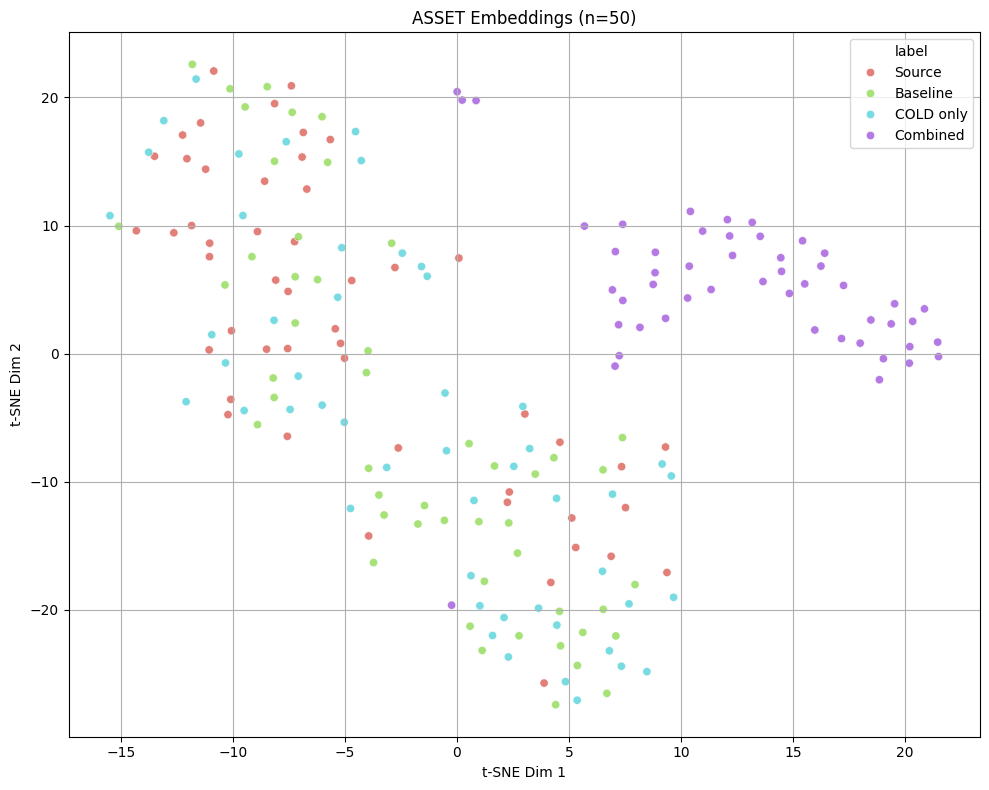

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def get_embedding(text: str, model: GPT2LMHeadModel) -> torch.Tensor:
    """Mean-pool the last hidden state over the sequence dimension."""
    if not text or not text.strip():
        return torch.zeros(768)
    model.eval()
    with torch.no_grad():
        inputs = tokenizer(
            text, return_tensors="pt", truncation=True, max_length=Config.MAX_LENGTH
        ).to(Config.DEVICE)
        outputs = model.transformer(inputs["input_ids"], output_hidden_states=True)
        last_hidden = outputs.last_hidden_state
        if last_hidden.shape[1] == 0:
            return torch.zeros(last_hidden.shape[2])
        return last_hidden.mean(dim=1).squeeze(0).cpu()


def visualize_embeddings_tsne(
    embeddings: np.ndarray,
    labels: List[str],
    title: str = "t-SNE Visualization",
    perplexity: int = 20
):
    """Fit t-SNE and plot a scatter plot colored by label."""
    if embeddings.shape[0] < 2:
        print("Not enough data points for t-SNE.")
        return

    perplexity = max(2, min(perplexity, embeddings.shape[0] - 1))
    tsne = TSNE(n_components=2, random_state=Config.SEED, perplexity=perplexity,
                init="random", learning_rate="auto")
    tsne_results = tsne.fit_transform(embeddings)

    df = pd.DataFrame(tsne_results, columns=["x", "y"])
    df["label"] = labels

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x="x", y="y", hue="label",
        palette=sns.color_palette("hls", len(np.unique(labels))),
        data=df, legend="full", alpha=0.8
    )
    plt.title(title)
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Collect embeddings from results
all_embeddings, all_labels = [], []
n = len(results["sources"])
for i in range(n):
    all_embeddings.append(get_embedding(results["sources"][i], base_model))
    all_embeddings.append(get_embedding(results["baseline"][i], base_model))
    all_embeddings.append(get_embedding(results["cold_only"][i], base_model))
    all_embeddings.append(get_embedding(results["combined"][i], finetuned_model))
    all_labels += ["Source", "Baseline", "COLD only", "Combined"]

valid = [(e, l) for e, l in zip(all_embeddings, all_labels)
         if not torch.equal(e, torch.zeros_like(e))]
emb_np = np.vstack([e.numpy() for e, _ in valid])
labels_filt = [l for _, l in valid]

visualize_embeddings_tsne(emb_np, labels_filt, title=f"ASSET Embeddings (n={n})")